In [1]:
cd geo_scan_git/

/share/nas2/pryder/geo_scan_git


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from utils import range_finder_general, peak_finder_general, offset_calculator, plot_target, single_gaussian_fitter
from scipy.interpolate import interp1d

In [3]:
pri = 20e-3 
samp_rate = 16e6
c= 299792458
points = int(samp_rate*pri)

In [4]:
# loading in previously processed observation array
end_arr = np.load('/share/nas2/pryder/thor6_range_peaks_pt1.npy')

# resampling data
num_resampled = 70
original_axis = np.linspace(0, 1, 7)
enlarged_axis = np.linspace(0, 1, num_resampled)

f = interp1d(original_axis, end_arr,  axis=0, kind='linear')
data_resampled = f(enlarged_axis)

# setting up pointing offsets from experiment plan
az_offset_1 = np.array([-0.315, -0.21, -0.105, 0, 0.105, 0.21, 0.315])
az_offset_2 = np.array([-0.1575, -0.105, -0.0525, 0, 0.0525, 0.105, 0.1575])

In [5]:
thor_5_az_1 = offset_calculator(32487, 0, True, 'active_sats_051125.csv', True, 36033)
thor_7_az_1 = offset_calculator(40613, 0, True, 'active_sats_051125.csv', True, 36033)
thor_6_az_1 = offset_calculator(36033, 0, True, 'active_sats_051125.csv', True, 36033)
intelsat_az_1 = offset_calculator(28358, 0, True, 'active_sats_051125.csv', True, 36033)

#### No range information tle overlay

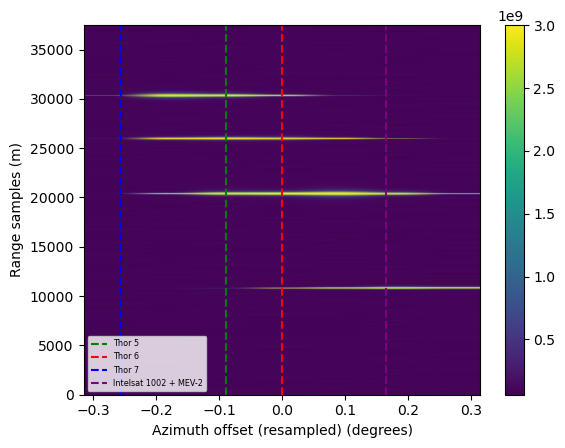

In [6]:
range_axis = np.linspace(0, pri * c / 2, points)
range_max = range_axis[222500] - range_axis[218500]
range_arr = np.linspace(0, range_max, 4000)

plt.imshow(end_arr.T, origin='lower', vmax=3e9, aspect='auto', extent=[az_offset_1[0], az_offset_1[-1], 0, range_max])
plt.xlabel('Azimuth offset (resampled) (degrees)')
plt.colorbar()

plt.vlines(thor_5_az_1[3], ymin=0, ymax=range_max, colors='g', label='Thor 5', linestyles='dashed')
plt.vlines(thor_6_az_1[3], ymin=0, ymax=range_max, colors='red', label='Thor 6', linestyles='dashed')
plt.vlines(thor_7_az_1[3], ymin=0, ymax=range_max, colors='blue', label='Thor 7', linestyles='dashed')
plt.vlines(intelsat_az_1[3], ymin=0, ymax=range_max, colors='purple', label='Intelsat 1002 + MEV-2', linestyles='dashed')

plt.ylabel('Range samples (m)')
plt.legend(fontsize='xx-small', loc=3)
plt.title('')
plt.show()

#### Adding range information

In [8]:
norad_list = [32487, 40613, 36033, 28358]
range_list = []
range_rate_list = []
for i in norad_list:
    print(range_finder_general(i))
    range_list.append(range_finder_general(i)[2])
    range_rate_list.append(range_finder_general(i)[1])

(np.float64(74813.08809365574), np.float64(0.12821297781728044), np.float64(39886.01319322256))
(np.float64(74826.27561390019), np.float64(0.12722242117326743), np.float64(39892.60695334479))
(np.float64(74805.21777049424), np.float64(-0.028002004564491235), np.float64(39882.078031641824))
(np.float64(74784.82229902629), np.float64(0.22992563751051986), np.float64(39871.880295907846))


In [9]:
range_list

[np.float64(39886.01319322256),
 np.float64(39892.60695334479),
 np.float64(39882.078031641824),
 np.float64(39871.880295907846)]

In [ ]:
#aligning the range information with the samples
test = [(x/2)*1000 for x in range_list]
test = [x-35335177 for x in test]
print(test)

[np.float64(2071367.0468278676), np.float64(2077960.8069500923), np.float64(2067431.8852471188), np.float64(2057234.1495131403)]


In [10]:
test = [x*1000 for x in range_list]

In [11]:
test

[np.float64(39886013.19322256),
 np.float64(39892606.953344785),
 np.float64(39882078.031641826),
 np.float64(39871880.29590785)]

In [13]:
test_y = [1e12, 1e12, 1e12, 1e12]

In [22]:
test_x = end_arr.sum(axis=0)
test_x = test_x
test_x

array([6.77152705e+08, 6.92110931e+08, 6.37975659e+08, ...,
       6.47043153e+08, 6.28001696e+08, 6.56763331e+08], shape=(4000,))

In [110]:
test = [x*1000 for x in range_list]
test = [x-3.98604e7 for x in test]
test = [x/10 for x in test]

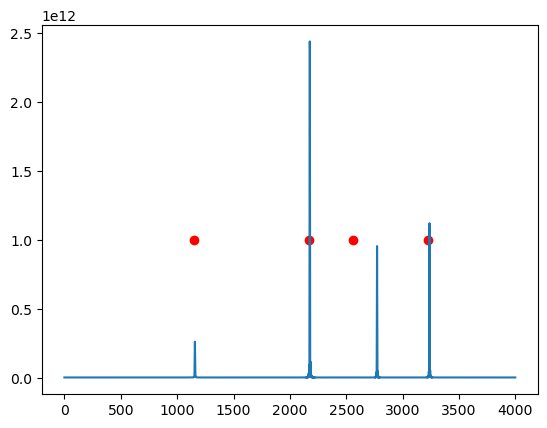

In [111]:
plt.plot(test_x)
plt.scatter(test, test_y, color='r')

In [113]:
# sample range found by looking at peak in range

thor_5_range = 2773
thor_7_range = 3238
thor_6_range = 2176
intelsat_range = 1157

In [122]:
test = [x*1000 for x in range_list]
test

[np.float64(39886013.19322256),
 np.float64(39892606.953344785),
 np.float64(39882078.031641826),
 np.float64(39871880.29590785)]

/tmp/ipykernel_123818/1446943096.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize='xx-small', loc=3)


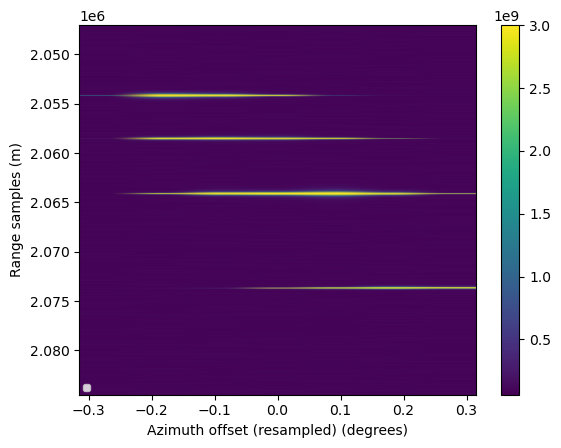

In [124]:
range_axis = np.linspace(0, pri * c / 2, points)
range_max = range_axis[222500] - range_axis[218500]
range_arr = np.linspace(0, range_max, 4000)
test_2 = [x-test[2] for x in test]
test_3 = [x+range_arr[thor_6_range] for x in test_2]
test_3=test
plt.imshow(end_arr.T, origin='lower', vmax=3e9, aspect='auto', extent=[az_offset_1[0], az_offset_1[-1], range_axis[222500], range_axis[218500]])
plt.xlabel('Azimuth offset (resampled) (degrees)')
plt.colorbar()
# plt.scatter(thor_5_az_1[3], test_3[0], c='g', label='Thor 5')
# plt.scatter(thor_6_az_1[3], test_3[2], c='r', label='Thor 6')
# plt.scatter(thor_7_az_1[3], test_3[1], c='blue', label='Thor 7')
# plt.scatter(intelsat_az_1[3], test_3[3], c='purple', label='Intelsat 1002 + MEV-2')

plt.ylabel('Range samples (m)')
plt.legend(fontsize='xx-small', loc=3)
plt.title('')
plt.show()

In [ ]:
thor_6_peak = peak_finder_general(thor_6_range, num_resampled, data_resampled)
thor_5_peak = peak_finder_general(thor_5_range, num_resampled, data_resampled)
thor_7_peak = peak_finder_general(thor_7_range, num_resampled, data_resampled)
intelsat_peak = peak_finder_general(intelsat_range, num_resampled, data_resampled)

## Gaussian fitting

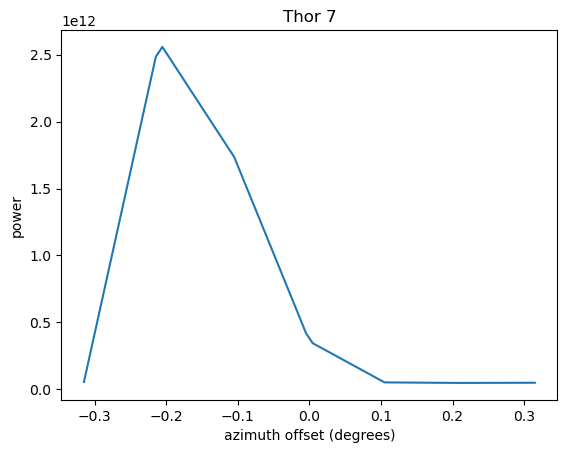

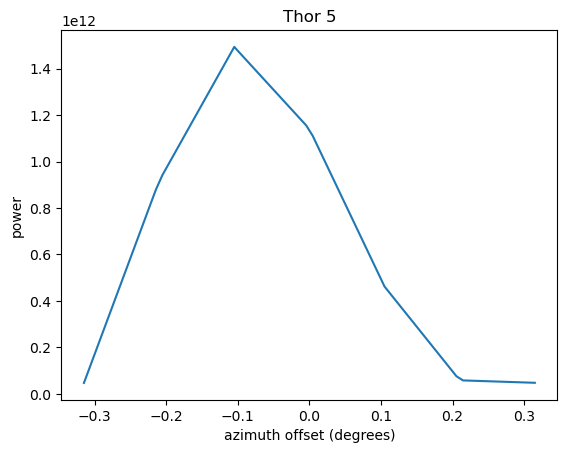

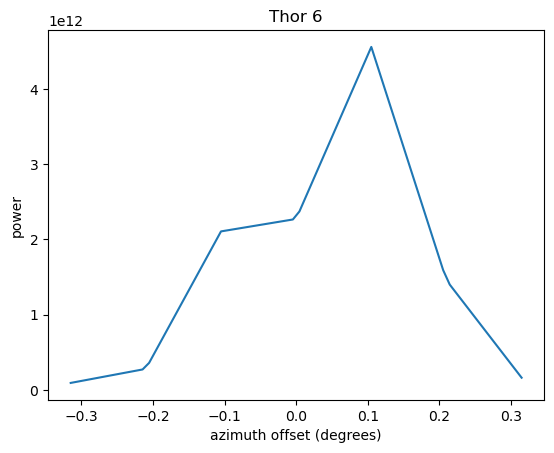

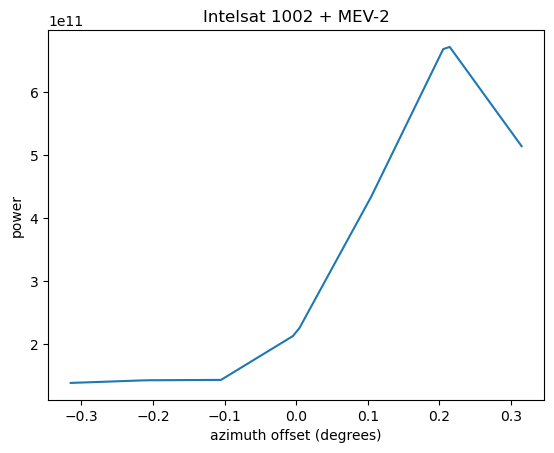

In [ ]:
# plotting individual targets
plot_target(3000, 3500, 'Thor 7', data_resampled)
plot_target(2500, 3000, 'Thor 5', data_resampled)
plot_target(1500, 2500, 'Thor 6', data_resampled)
plot_target(0, 1500, 'Intelsat 1002 + MEV-2', data_resampled)

In [ ]:
#fitting gaussians
single_gaussian_fitter( 3000, 3500, data_resampled, -0.3, 0.1, 'Thor 7')

NameError: name 'thor_5_peak' is not defined

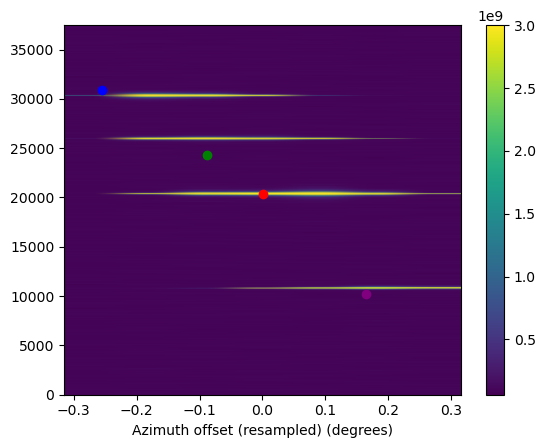

In [125]:
range_axis = np.linspace(0, pri * c / 2, points)
range_max = range_axis[222500] - range_axis[218500]
range_arr = np.linspace(0, range_max, 4000)
test_2 = [x-test[2] for x in test]
test_3 = [x+range_arr[thor_6_range] for x in test_2]
plt.imshow(end_arr.T, origin='lower', vmax=3e9, aspect='auto', extent=[az_offset_1[0], az_offset_1[-1], 0, range_max])
plt.xlabel('Azimuth offset (resampled) (degrees)')
plt.colorbar()
# plt.scatter(thor_5_peak, range_arr[thor_5_range], c='white') #c='g', label='Thor 5')
# plt.scatter(thor_6_peak, range_arr[thor_6_range], c='white')#c='r', label='Thor 6')
# plt.scatter(thor_7_peak, range_arr[thor_7_range], c='white')#c='blue', label='Thor 7')
# plt.scatter(intelsat_peak, range_arr[intelsat_range], c='white', label='Observation Peaks') #c='purple', label='Intelsat 1002 + MEV-2')
plt.scatter(thor_5_az_1[3], test_3[0], c='g', label='Thor 5')
plt.scatter(thor_6_az_1[3], test_3[2], c='r', label='Thor 6')
plt.scatter(thor_7_az_1[3], test_3[1], c='blue', label='Thor 7')
plt.scatter(intelsat_az_1[3], test_3[3], c='purple', label='Intelsat 1002 + MEV-2')
plt.errorbar(thor_5_peak, range_arr[thor_5_range], yerr=0, xerr=0.006, ecolor='white')
plt.errorbar(thor_6_peak, range_arr[thor_6_range], yerr=0, xerr=0.002, ecolor='white')
plt.errorbar(thor_7_peak, range_arr[thor_7_range], yerr=0, xerr=0.006, ecolor='white')
plt.errorbar(intelsat_peak, range_arr[intelsat_range], yerr=0, xerr=0.0009, ecolor='white', label='Observation Peaks')
# plt.vlines(thor_5_az_1[3], ymin=0, ymax=range_max, colors='g', label='Thor 5', linestyles='dashed')
# plt.vlines(thor_6_az_1[3], ymin=0, ymax=range_max, colors='red', label='Thor 6', linestyles='dashed')
# plt.vlines(thor_7_az_1[3], ymin=0, ymax=range_max, colors='blue', label='Thor 7', linestyles='dashed')
# plt.vlines(intelsat_az_1[3], ymin=0, ymax=range_max, colors='purple', label='Intelsat 1002 + MEV-2', linestyles='dashed')
# plt.vlines(thor_6_range, ymin=thor_6_az_2[-1], ymax=thor_6_az_2[0], colors='black', label='Thor 6', linestyles='dashed')
# plt.vlines(thor_7_range, ymin=thor_7_az_2[-1], ymax=thor_7_az_2[0], colors='blue', label='Thor 7', linestyles='dashed')
# plt.vlines(intelsat_range, ymin=intelsat_az_2[-1], ymax=intelsat_az_2[0], colors='purple', label='Intelsat 1002 + MEV-2', linestyles='dashed')

# plt.ylim((-0.315, 0.315))



plt.ylabel('Range samples (m)')
plt.legend(fontsize='xx-small', loc=3)
plt.title('')
plt.show()